In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = pd.read_csv("../datasets/Indoor_Plant_Health_and_Growth_Factors.csv")
data.sample(5)

feature_columns = [
    'Soil_Moisture',
    'Humidity',
    'Ambient_Temperature',
    'Plant_ID'
    ]

target_column = 'Plant_Health_Status'

required_columns = feature_columns + [target_column]

missing_columns = [col for col in required_columns if col not in data.columns]

if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data[required_columns].dtypes)

print("\nMissing values per required column:")
print(data[required_columns].isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())

Dataset shape: (1000, 17)

Column names:
['Plant_ID', 'Height_cm', 'Leaf_Count', 'New_Growth_Count', 'Health_Notes', 'Watering_Amount_ml', 'Watering_Frequency_days', 'Light_Intensity', 'Ambient_Temperature', 'Humidity', 'Fertilizer_Type', 'Fertilizer_Amount_ml', 'Pest_Presence', 'Pest_Severity', 'Soil_Moisture', 'Soil_Type', 'Plant_Health_Status']

Data types:
Soil_Moisture          float64
Humidity               float64
Ambient_Temperature    float64
Plant_ID                   str
Plant_Health_Status      int64
dtype: object

Missing values per required column:
Soil_Moisture          0
Humidity               0
Ambient_Temperature    0
Plant_ID               0
Plant_Health_Status    0
dtype: int64

Duplicate rows: 0


In [19]:
dataset = data[required_columns].copy()
dataset = dataset.dropna()

print("\nShape after dropping missing values:", dataset.shape)

dataset.sample(5)


Shape after dropping missing values: (1000, 5)


,Soil_Moisture,Humidity,Ambient_Temperature,Plant_ID,Plant_Health_Status
395,11.1,47.7,22.3,Aloe vera,4
147,25.5,35.1,22.1,Chlorophytum comosum,5
437,12.0,56.1,23.4,Monstera deliciosa,3
791,52.1,69.2,24.8,Begonia maculata,5
579,19.5,60.4,25.2,Ficus lyrata,4


In [20]:
# def remap_health_status(value):
#     if value in [1, 2]:
#         return "High Stress"
#     elif value in [3, 4]:
#         return "Moderate Stress"
#     elif value == 5:
#         return "Healthy"
#     else:
#         return np.nan

In [21]:
dataset[target_column] = dataset[target_column]

dataset = dataset.dropna(subset=[target_column])

print("\nNew target distribution:")
print(dataset[target_column].value_counts())

dataset.sample(5)


New target distribution:
Plant_Health_Status
2    229
5    213
4    205
1    181
3    172
Name: count, dtype: int64


,Soil_Moisture,Humidity,Ambient_Temperature,Plant_ID,Plant_Health_Status
945,25.4,60.3,24.2,Calathea orbifolia,5
210,59.4,44.3,20.2,Monstera deliciosa,5
176,18.2,31.0,25.1,Spathiphyllum wallisii,2
361,36.9,68.4,26.1,Chlorophytum comosum,1
169,24.9,49.8,24.0,Begonia maculata,3



Target class distribution:
Plant_Health_Status
2    229
5    213
4    205
1    181
3    172
Name: count, dtype: int64


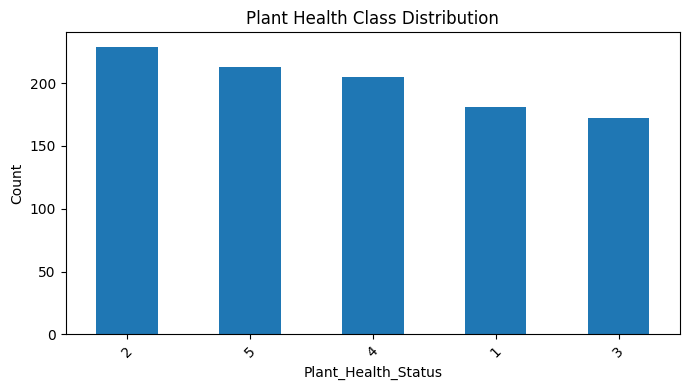

In [22]:
print("\nTarget class distribution:")
print(dataset[target_column].value_counts())

dataset[target_column].value_counts().plot(kind='bar', figsize=(7, 4))
plt.title("Plant Health Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
x = dataset[feature_columns]
x = pd.get_dummies(x, columns=['Plant_ID'])
y = dataset[target_column]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.21


In [24]:
print("Train set report:")
train_predictions = model.predict(x_train)
print(classification_report(y_train, train_predictions))

print("Test set report:")
test_predictions = model.predict(x_test)
print(classification_report(y_test, test_predictions))

Train set report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       145
           2       1.00      1.00      1.00       183
           3       1.00      1.00      1.00       138
           4       1.00      1.00      1.00       164
           5       1.00      1.00      1.00       170

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800

Test set report:
              precision    recall  f1-score   support

           1       0.17      0.14      0.15        36
           2       0.28      0.28      0.28        46
           3       0.15      0.12      0.13        34
           4       0.16      0.20      0.18        41
           5       0.25      0.28      0.26        43

    accuracy                           0.21       200
   macro avg       0.20      0.20      0.20       200
weighted avg       0.21      0.21      0.2

<Figure size 600x600 with 0 Axes>

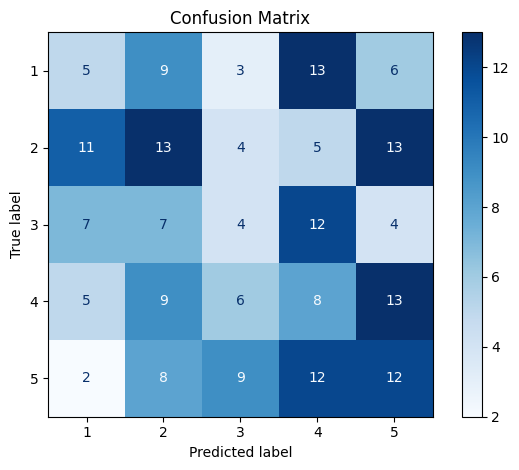

In [25]:
class_labels = sorted(y.unique())

cm = confusion_matrix(y_test, test_predictions, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

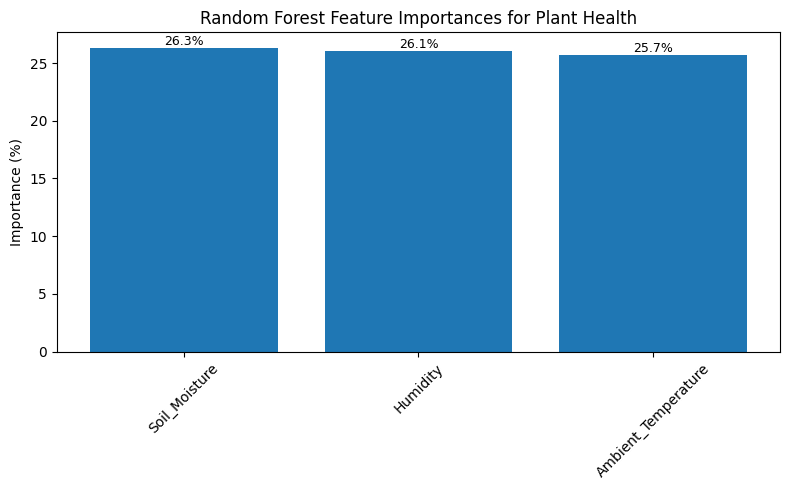

In [26]:
importances = model.feature_importances_
feature_names = x.columns

mask = ~feature_names.str.contains("Plant_ID")

filtered_importances = importances[mask]
filtered_feature_names = feature_names[mask]

importances_pct = filtered_importances * 100

indices = np.argsort(importances_pct)[::-1]

plt.figure(figsize=(8, 5))
bars = plt.bar(range(len(importances_pct)), importances_pct[indices])

plt.xticks(
    range(len(importances_pct)),
    filtered_feature_names[indices],
    rotation=45
)

plt.ylabel("Importance (%)")
plt.title("Random Forest Feature Importances for Plant Health")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [27]:
print("Dataset Validation Summary")
print("--------------------------")
print(f"Rows used: {len(dataset)}")
print(f"Features used: {feature_columns}")
print(f"Target classes: {sorted(y.unique().tolist())}")
print(f"Missing values removed: {data[required_columns].isnull().any(axis=1).sum()}")
print(f"Duplicate rows in original data: {data.duplicated().sum()}")
print(f"Test accuracy: {accuracy_score(y_test, test_predictions):.4f}")

Dataset Validation Summary
--------------------------
Rows used: 1000
Features used: ['Soil_Moisture', 'Humidity', 'Ambient_Temperature', 'Plant_ID']
Target classes: [1, 2, 3, 4, 5]
Missing values removed: 0
Duplicate rows in original data: 0
Test accuracy: 0.2100


# Mid Conclusion
As I am only looking for a model that can make decent accurate decisions with only a few parameters, this is what i tested.
Upon doing so, I noticed that the model had very poor accuracy, 0.36 at first. 
After thinking about it, i made the assumptions that root cause is that the Plant_ID is not used.
This would suggest that the model is trying to make predictions on something that has labels to it, which put weight on whether the plant is healthy.
Example, for a cactus low moisture, it is healthy, while for another plant, it can cause stress.

After including the plant type, it did increase in accuracy, but not significantly, it went up to 0.395.
More than half of the time, the prediction would be wrong regardless.

This made me wonder if in general, taking all the given labels, would result in a better model accuracy. 
Yet, this seemed to only make things worse as the accuracy collapsed down to 0.215 .
While it isn't completly certain what could cause this, my predeiction is a combination of several factors, such as label noise/ bad labeling, ro real signal, problem is temporal, but dataset is static ( the dataset is taken at one moment of time, while plant health can change over time). 

To actually partially idenitfy the problem within the dataset, we can plot it. 



Soil_Moisture          0.003656
Humidity               0.031807
Ambient_Temperature    0.064063
Plant_Health_Status    1.000000
Name: Plant_Health_Status, dtype: float64


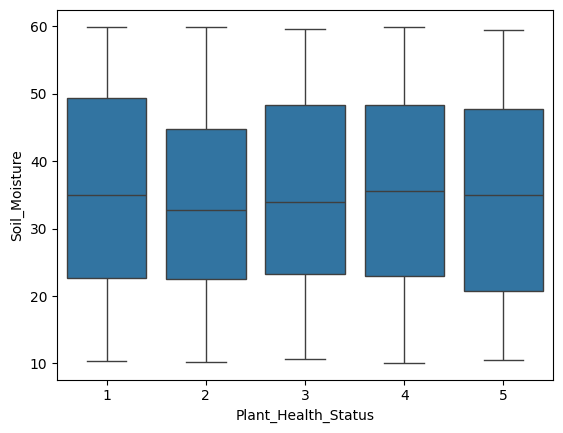

In [ ]:
dataset_numeric = dataset.copy()

print(dataset_numeric.corr(numeric_only=True)['Plant_Health_Status'])
import seaborn as sns

sns.boxplot(x='Plant_Health_Status', y='Soil_Moisture', data=dataset)
plt.show()

This plot and correlation, shows what was predecited. 
The values are near zero, meaning there is no relation between the various labels and the plant health.
To put it bluntly, yhe model cannot predict plant health from these features, because the features do not influence the target in this dataset.
Even when looking at the diffrent feature importances, it shows that all of them are pretty much similar, suggesting a weak signal.

Adding additional features such as light exposure, soil type, and pest presence did not improve model performance. Instead, it led to a decrease in accuracy. This indicates that the dataset likely contains noisy or inconsistent relationships between the features and the target variable. 

In a well-structured dataset, adding relevant features should improve predictive performance. The observed degradation suggests that the additional features do not provide meaningful or consistent information for predicting plant health.
